<a href="https://colab.research.google.com/github/FishyFoshy/COMP3608-Project/blob/main/Dataset_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All code was ran on VSCode. Any changes in output when ran on Google Colab is due to the difference in library versions that Google Colab uses compared to the ones used in the local environment at the time. Different library version may handle randomness differently, leading to the differences in output. The outputs left serve as a checkpoint of the results obtained when we ran the code.

In [ ]:
import os

try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    !git clone https://github.com/FishyFoshy/COMP3608-Project.git
    %cd COMP3608-Project

else:
    import subprocess
    import sys

    packages = [
        'numpy',
        'pandas',
        'scikit-learn',
        'matplotlib',
        'seaborn',
        'xgboost',
        'scipy',
        'notebook',
        'jupyter'
    ]

    for package in packages:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

    print("All packages installed!")

### Cleaning of Dataset 3

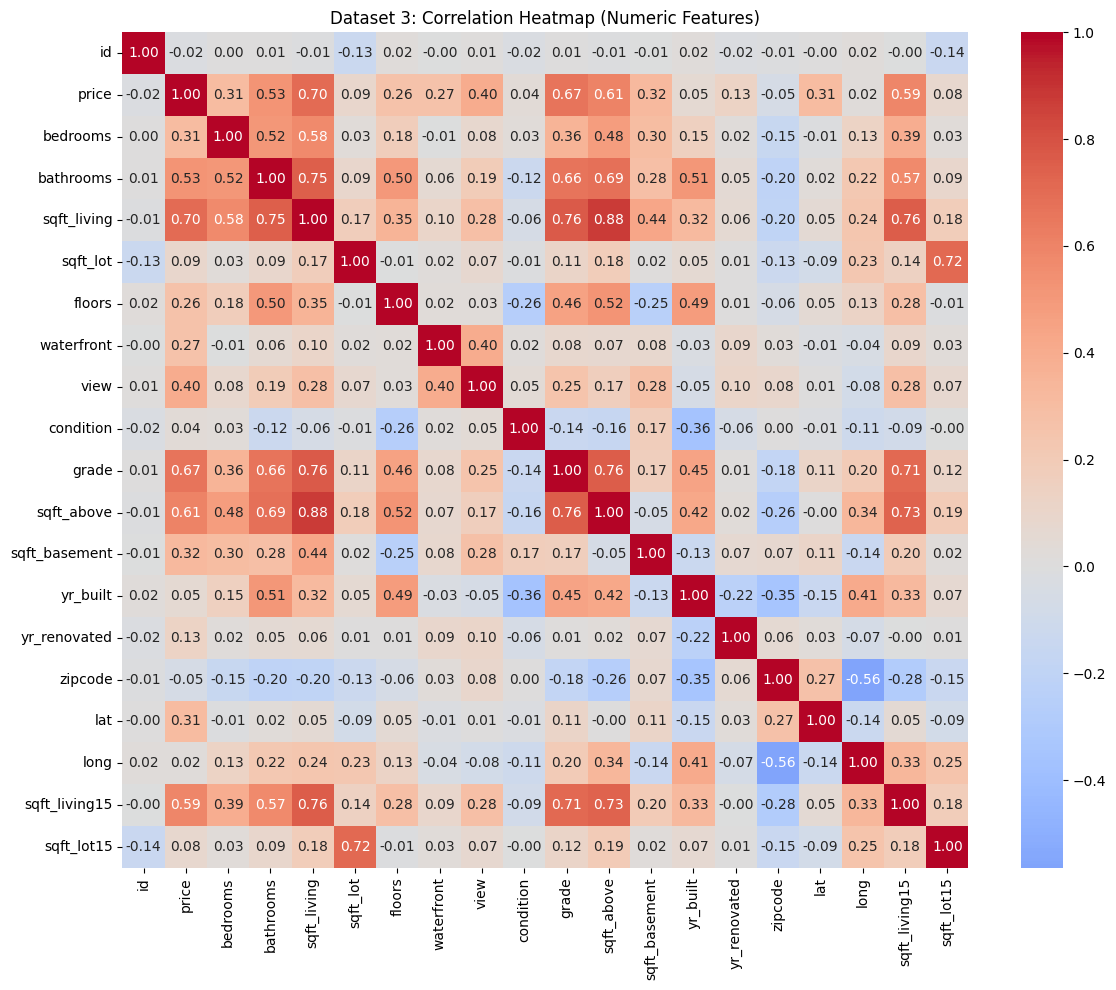

In [296]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Load datasets
df3 = pd.read_csv('kc_house_data.csv')

# Correlation heatmap for Dataset 1 (richest numeric features)
numeric_cols = df3.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df3[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Dataset 3: Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

### Pre-Cleaning Correlation Analysis

The heatmap above shows the correlations between all numeric features in the raw Dataset 3 (`kc_house_data.csv`). This encourages the column drops that were made in the cleaning process:

- `id` has a near-zero correlation with every other feature (-0.02 with `price`) and with all predictors. It is a row identifier with no predictive value and would only introduce noise if retained.

- `date` is a string column representing the sale date and therefore does not appear in the numeric correlation matrix. It carries no direct price signal and is dropped to keep the feature space straightforward.

- `yr_renovated` shows a weak correlation with `price` (0.13). More importantly, the vast majority of properties have a value of 0 (never renovated), making it a highly sparse.

- `zipcode` appears numeric but functions as a categorical area code and its correlation with `price` is effectively zero (-0.05), not to mention, location is already captured more informatively by `lat` and `long`.

- `sqft_living15` (average living area of the 15 nearest neighbours) has a high correlation with `sqft_living` (0.76) and `sqft_above` (0.73). Retaining it alongside the property's own square footage would introduce strong multicollinearity without adding independent information.

- `sqft_lot15` (average lot size of the 15 nearest neighbours) is highly correlated with `sqft_lot` (0.72), making it largely redundant. Dropping it removes the multicollinearity while preserving all relevant lot-size information through `sqft_lot`.

In [297]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Drops all unnecessary columns
df3 = df3.drop(columns=['id', 'date', 'yr_renovated', 'zipcode', 'sqft_living15', 'sqft_lot15'])

# Drops all with null values
df3.dropna(inplace=True)

# Apply log transform to the target
df3['price'] = np.log(df3['price'])

# Remove the top 1% highest prices to reduce high-end outliers before log-transform
df3_outr = df3.copy()
upper_quantile = df3_outr['price'].quantile(0.99)
df3_outr = df3_outr[df3_outr['price'] <= upper_quantile]

# Create a copy of df3 for Linear Regression before feature engineering
df3lr = df3.copy()

# Apply location-based feature engineering to df3lr only (for Linear Regression)
df3lr['lat_lon_interaction'] = df3lr['lat'] * df3lr['long']
center_lat = df3lr['lat'].mean()
center_lon = df3lr['long'].mean()
df3lr['dist_to_center'] = np.sqrt((df3lr['lat'] - center_lat)**2 + (df3lr['long'] - center_lon)**2)
df3lr = df3lr.drop(columns=['lat', 'long'])  # Drop original lat/lon to avoid multicollinearity

# Separates non numerical columns from numerical ones
non_numerical_columns = ['price']

# Process df3lr (for Linear Regression): scale and encode
numerical_features_lr = [col for col in df3lr.columns if col not in non_numerical_columns]
scaler_lr = StandardScaler()
df3lr[numerical_features_lr] = scaler_lr.fit_transform(df3lr[numerical_features_lr])
categorical_cols_lr = df3lr.select_dtypes(include='object').columns
df3lr = pd.get_dummies(df3lr, columns=categorical_cols_lr, drop_first=True)

target_column = 'price'
x_lr = df3lr[[col for col in df3lr.columns if col != target_column]].copy()
y_lr = df3lr[target_column].copy()
x_train_lr, x_test_lr, y_train_lr, y_test_lr = train_test_split(x_lr, y_lr, test_size=0.2, random_state=42)

# Process df3 (for tree models: Random Forest, XGBoost): keep raw lat/lon, scale and encode
numerical_features = [col for col in df3.columns if col not in non_numerical_columns]
scaler = StandardScaler()
df3[numerical_features] = scaler.fit_transform(df3[numerical_features])
categorical_cols_to_encode = df3.select_dtypes(include='object').columns
df3 = pd.get_dummies(df3, columns=categorical_cols_to_encode, drop_first=True)

features = [col for col in df3.columns if col != target_column]
x = df3[features].copy()
y = df3[target_column].copy()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("=" * 60)
print("DATASET 3: kc_house_data.csv")
print("=" * 60)
print("\nFirst 10 rows:")
display(df3.head(10))
print("\nData types:")
print(df3.dtypes)
print("\nMissing values:")
print(df3.isnull().sum())
print("\nTarget variable (price) statistics:")
print(df3['price'].describe())

DATASET 3: kc_house_data.csv

First 10 rows:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,lat,long
0,12.309982,-0.398737,-1.447464,-0.979835,-0.228321,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.734708,-0.658681,-0.544898,-0.352572,-0.306079
1,13.195614,-0.398737,0.175607,0.533634,-0.189885,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.460841,0.245141,-0.681079,1.161568,-0.746341
2,12.100712,-1.473959,-1.447464,-1.426254,-0.123298,-0.915427,-0.087173,-0.305759,-0.629187,-1.409587,-1.229834,-0.658681,-1.293892,1.283537,-0.135655
3,13.311329,0.676485,1.149449,-0.130550,-0.244014,-0.915427,-0.087173,-0.305759,2.444294,-0.558836,-0.891699,1.397515,-0.204446,-0.283288,-1.271816
4,13.142166,-0.398737,-0.149007,-0.435422,-0.169653,-0.915427,-0.087173,-0.305759,-0.629187,0.291916,-0.130895,-0.658681,0.544548,0.409550,1.199335
5,14.018451,0.676485,3.097133,3.636791,2.096185,-0.915427,-0.087173,-0.305759,-0.629187,2.844170,2.537955,2.798440,1.021181,0.693181,1.483375
6,12.458775,-0.398737,0.175607,-0.397313,-0.200098,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,-0.088628,-0.658681,0.816910,-1.806810,-0.803149
7,12.583995,-0.398737,-0.798235,-1.110494,-0.130276,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.879623,-0.658681,-0.272536,-1.086547,-0.717937
8,12.343658,-0.398737,-1.447464,-0.326539,-0.184381,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.891699,0.990795,-0.374672,-0.344633,-0.874160
9,12.685408,-0.398737,0.500221,-0.206768,-0.206351,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.122706,-0.658681,1.089271,-1.383168,1.298749



Data types:
price            float64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition        float64
grade            float64
sqft_above       float64
sqft_basement    float64
yr_built         float64
lat              float64
long             float64
dtype: object

Missing values:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
lat              0
long             0
dtype: int64

Target variable (price) statistics:
count    21613.000000
mean        13.047817
std          0.526685
min         11.225243
25%         12.682152
50%         13.017003
75%         13.377006
max         15.856731
Name: price, dtype: float64


In [298]:
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import numpy as np
# Inverse the log transformation to its original scale

def rmse_original_scale(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    # Calculate RMSE on the original scale
    return np.sqrt(mean_squared_error(y_true_original, y_pred_original))

def mae_original_scale(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    # Calculate MAE on the original scale
    return mean_absolute_error(y_true_original, y_pred_original)

def r2_original_scale(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    # Calculate R2 on the original scale
    return r2_score(y_true_original, y_pred_original)

# Create scorers that can be used with cross_val_score
scoring_dict = {
    'rmse': make_scorer(rmse_original_scale, greater_is_better=False),
    'mae': make_scorer(mae_original_scale, greater_is_better=False),
    'r2': make_scorer(r2_original_scale, greater_is_better=True)
}

# Linear Regression for Dataset 3

In [299]:
from sklearn.model_selection import cross_val_score,cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,root_mean_squared_error,get_scorer_names, make_scorer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn import metrics

model = LinearRegression()
model.fit(x_train,y_train)
predictions = model.predict(x_test)

----Log Space Metrics---
RMSE: $0.26
MAE: $0.20
r2: 0.7602

--- Real-Space Metrics ---
RMSE: $330,922.02
MAE: $120,547.23
r2: 0.2756

--- Cross Validated Scores ---
RMSE: $232,846.86
MAE: $114,168.65
r2: 0.5710



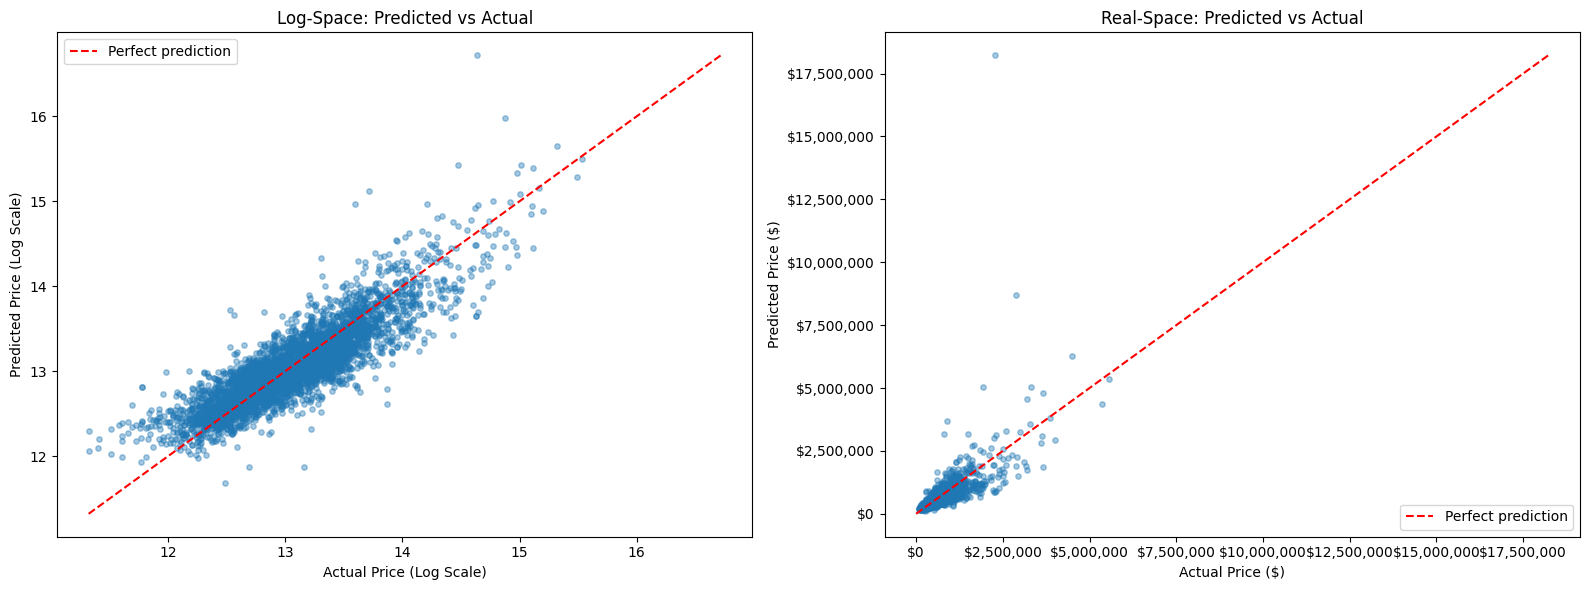

In [ ]:
y_test_real = np.exp(y_test)
predictions_real = np.exp(predictions)

print("----Log Space Metrics---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test, predictions):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test, predictions):,.2f}")
print(f"r2: {metrics.r2_score(y_test, predictions):.4f}\n")

print("--- Real-Space Metrics ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, predictions_real):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test_real, predictions_real):,.2f}")
print(f"r2: {metrics.r2_score(y_test_real, predictions_real):.4f}\n")

cv_results = cross_validate(model, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(y_test, predictions, alpha=0.4, s=15)
max_val_log = max(y_test.max(), predictions.max())
min_val_log = min(y_test.min(), predictions.min())
ax1.plot([min_val_log, max_val_log], [min_val_log, max_val_log], 'r--', label='Perfect prediction')
ax1.set_xlabel('Actual Price (Log Scale)') 
ax1.set_ylabel('Predicted Price (Log Scale)')
ax1.set_title('Log-Space: Predicted vs Actual')
ax1.legend()

ax2.scatter(y_test_real, predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Real-Space: Predicted vs Actual')
ax2.legend()

# Format the Real-Space graph to show dollar amounts
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

This dataset contains a small number of significant outliers. Even with a log transformation, these values remain too far from the majority of the data to allow for reliable predictions regarding high-end mansions. This small subset of extremely expensive properties violates the assumption of homoscedasticity (equal variance) required for linear regression.

Consequently, for this dataset, one can achieve a reasonably accurate model if the primary goal is to determine which 'price bucket' a house falls into; this explains the respectable R2 value of 0.76 in log space. However, as soon as granularity is reintroduced by converting the predictions back to their original scale, errors are magnified and accuracy plummets.

Given these constraints, it is logical to develop two separate models: one operating in log space(using log10)to identify extremely high-value properties, and another designed to differentiate between houses with price differences of less than $500,000.

Constructing the two linear models 

## Linear Model with the Outliers Removed

RMSE: $167,031.23
MAE: $103,687.01
r2: 0.6492

Cross-validation RMSE:	$165,239.23
Cross-validation MAE:	$105,081.07
Cross-validation R²:	0.6621


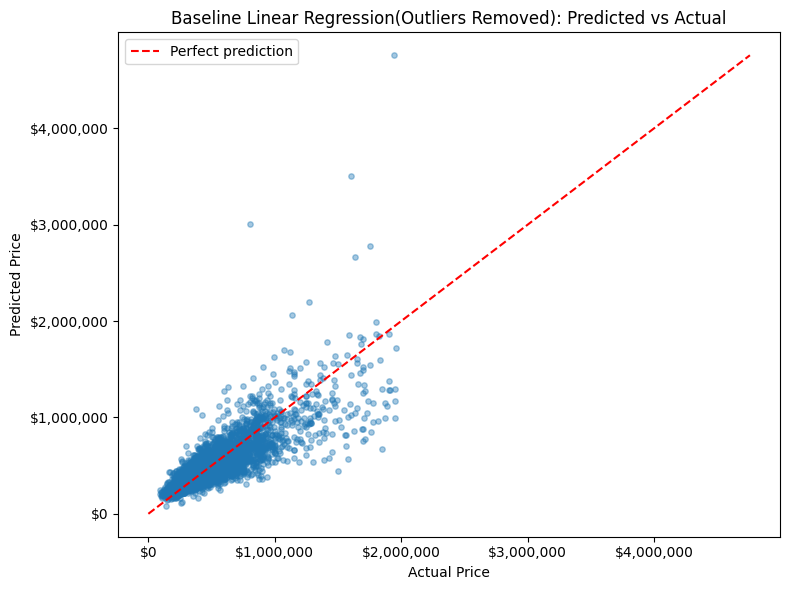

In [301]:
# Scale numerical features
scaler = StandardScaler()
df3_outr[numerical_features] = scaler.fit_transform(df3_outr[numerical_features])

# One-Hot Encodes all categorical data
categorical_cols_to_encode = df3_outr.select_dtypes(include='object').columns
df3_outr = pd.get_dummies(df3_outr, columns=categorical_cols_to_encode, drop_first=True)

#Extracting Features
target_column = 'price'
features = [col for col in df3_outr.columns if col != target_column]

#Creating "X" and "Y"
x_g = df3_outr[features].copy()
y_g = df3_outr[target_column].copy()

#Creating split
x_train_g, x_test_g, y_train_g, y_test_g = train_test_split(x_g, y_g, test_size=0.2, random_state=42)

#Creating Model
model_1 = LinearRegression()
model_1.fit(x_train_g, y_train_g)
predictions = model_1.predict(x_test_g)

#Printing Metrics
print(f"RMSE: ${rmse_original_scale(y_test_g, predictions):,.2f}")
print(f"MAE: ${mae_original_scale(y_test_g, predictions):,.2f}")
print(f"r2: {r2_original_scale(y_test_g, predictions):.4f}")

cv_results = cross_validate(model_1, x_g, y_g, cv=5, scoring=scoring_dict, return_train_score=True)

#Cross Validated Metrics
print(f"\nCross-validation RMSE:\t${-cv_results['test_rmse'].mean():,.2f}")
print(f"Cross-validation MAE:\t${-cv_results['test_mae'].mean():,.2f}")
print(f"Cross-validation R²:\t{cv_results['test_r2'].mean():.4f}")

y_test_real = np.exp(y_test_g)
predictions_real = np.exp(predictions)

#Plotting Curve of Prediction vs Actual to show the accuracy 
plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, predictions_real, alpha=0.4, s=15)
max_val = max(y_test_real.max(), predictions_real.max()) 
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price')
plt.title('Baseline Linear Regression(Outliers Removed): Predicted vs Actual')
plt.legend()
ax = plt.gca() 
import matplotlib.ticker as ticker # Ensure ticker is imported
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tight_layout()  
plt.show()

This model is more in line with what you'd expect from a well constructed linear model the measures of varaince and graphs are all within acceptable parameters. You could make the model even more accurate by getting rid of the cluster past 2 million this would yield a model closer to 75% however culling good data is generally bad practice in Machine Learning/Data Science.

### Further Analyisis of the Model with the Outliers Removed

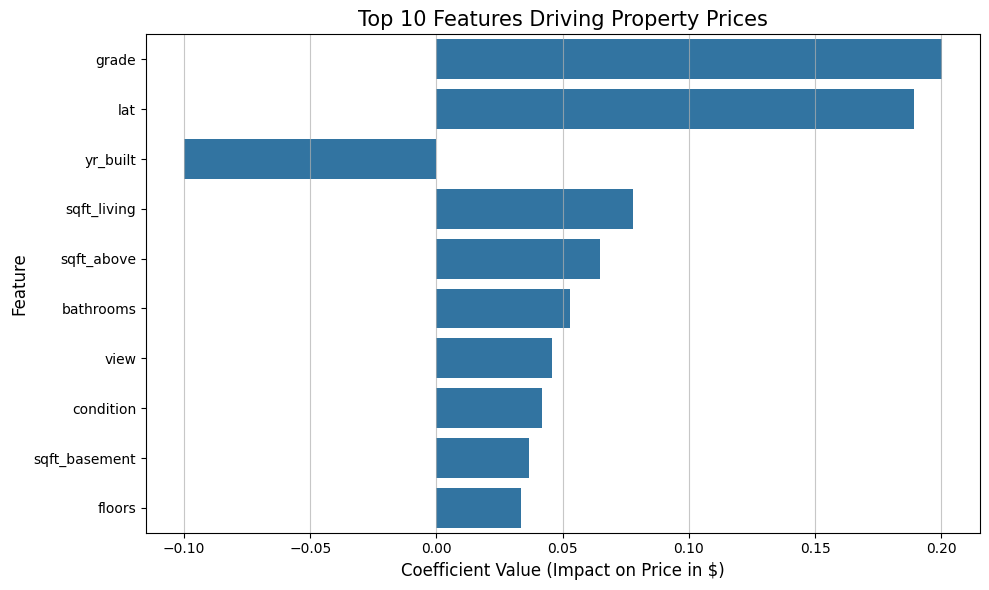

,Feature,Coefficient
8,grade,0.200341
12,lat,0.189159
11,yr_built,-0.100073
2,sqft_living,0.077903
9,sqft_above,0.064843
1,bathrooms,0.053105
6,view,0.045771
7,condition,0.041898
10,sqft_basement,0.036656
4,floors,0.033563


In [302]:
import seaborn as sns
#Fetching Feature Names and Coefficents
feature_names = x_train_g.columns
coefficients = model_1.coef_

#Wrapping them together in a Pandas DataFrame for Easy Comparision and Viewing
feature_importance = pd.DataFrame({
 'Feature': feature_names,
 'Coefficient': coefficients
})

#Using the Absolute Function in the NumPy Library before Sorting the Coefficents in Decending Order
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_10_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
 data=top_10_features, 
 x='Coefficient', 
 y='Feature', 
)

#Graph of the Top 10 features
plt.title('Top 10 Features Driving Property Prices', fontsize=15)
plt.xlabel('Coefficient Value (Impact on Price in $)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features[['Feature', 'Coefficient']])

According to the graph, the one negative predictor at the top 10 features is yr_built. The later the houses are constructed, the lower the estimated price of the houses when all other characteristics remain constant. This could be because more recent developments are often sold by institutional investors who are incentivised to sell inventory at a high price within a short period of time at or below market prices, whereas older homes are normally sold through conventional methods at full market value.

The strongest positive predictor is grade (build quality) with the next highest being lat (latitude) by a small margin. The dominance of latitude indicates the geographic premiums that are assigned to the properties in more northerly (higher-latitude) neighbourhoods within this dataset.

The rest of the positive predictors, which include: sqft_living, sqft_above, view, bathrooms, waterfront, sqft_basement and condition follow more traditional expectations in that larger, better-positioned, and feature-rich properties command higher prices. It is worth noting that the quality of a building ( `grade` ) and location ( `lat` ) has an enormous influence on the estimated price.

## Log Scaled Model Features Evaulation

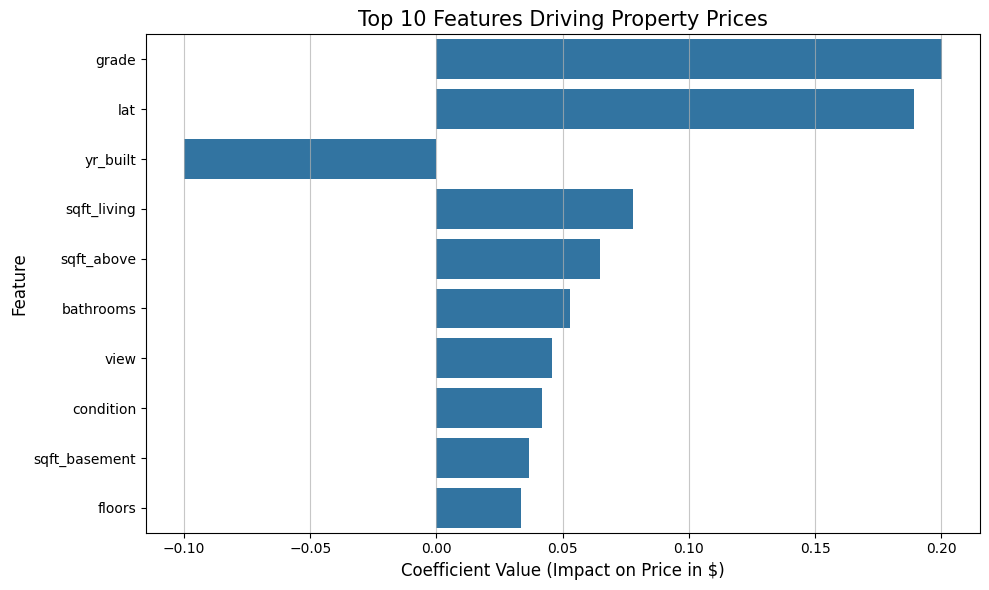

,Feature,Coefficient
8,grade,0.200341
12,lat,0.189159
11,yr_built,-0.100073
2,sqft_living,0.077903
9,sqft_above,0.064843
1,bathrooms,0.053105
6,view,0.045771
7,condition,0.041898
10,sqft_basement,0.036656
4,floors,0.033563


In [303]:
#Fetching Feature Names and Coefficents
feature_names = x_train.columns
coefficients = model_1.coef_

#Wrapping them together in a Pandas DataFrame for Easy Comparision and Viewing
feature_importance = pd.DataFrame({
 'Feature': feature_names,
 'Coefficient': coefficients
})

#Using the Absolute Function in the NumPy Library before Sorting the Coefficents in Decending Order
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_10_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
 data=top_10_features, 
 x='Coefficient', 
 y='Feature', 
)
#Graph of the Top 10 features
plt.title('Top 10 Features Driving Property Prices', fontsize=15)
plt.xlabel('Coefficient Value (Impact on Price in $)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features[['Feature', 'Coefficient']])

The target variable (price) was only subjected to the log transform, as opposed to the feature X. Since the predictors themselves are the same, the ranking and direction of each coefficient are the same as in the previous model, with grade staying the strongest positive predictor, lat second and yr built the only negative predictor.

The relative ranking and the logic discussed in the outliers-eliminated analysis holds: the quality of the building and the location drive the price upwards, whereas the more recent the building is constructed, the lower the predicted value.

## Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=5)

print("Training Random Forest... This may take a moment depending on dataset size.")
rf_model.fit(x_train, y_train)

# Generate predictions on the log-scaled test set
rf_predictions = rf_model.predict(x_test)

#Generate Cross Validation Metrics in Log Space
print("\n--- Log-Space Metrics (Random Forest) ---")
print(f"RMSE: {metrics.root_mean_squared_error(y_test, rf_predictions):.4f}")
print(f"MAE:  {metrics.mean_absolute_error(y_test, rf_predictions):.4f}")
print(f"R²:   {metrics.r2_score(y_test, rf_predictions):.4f}\n")

print(f"\nCross-validation RMSE:\t{-cross_val_score(rf_model, x, y, cv=5, scoring='neg_root_mean_squared_error').mean():,.2f}")
print(f"Cross-validation MAE:\t{-cross_val_score(rf_model, x, y, cv=5, scoring='neg_mean_absolute_error').mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(rf_model, x, y, cv=5, scoring='r2').mean():.4f}")

#Real Space Metrics
y_test_real = np.exp(y_test)
rf_predictions_real = np.exp(rf_predictions)

print("\n--- Real-Space (Dollar) $ Metrics (Random Forest) ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, rf_predictions_real):,.2f}")
print(f"MAE:  ${metrics.mean_absolute_error(y_test_real, rf_predictions_real):,.2f}")
print(f"R²:   {metrics.r2_score(y_test_real, rf_predictions_real):.4f}\n")

# Cross Validation for the RF model
cv_results = cross_validate(rf_model, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

Training Random Forest... This may take a moment depending on dataset size.

--- Log-Space Metrics (Random Forest) ---
RMSE: 0.1778
MAE:  0.1269
R²:   0.8890


Cross-validation RMSE:	0.18
Cross-validation MAE:	0.13
Cross-validation R²:	0.8871

--- Real-Space (Dollar) $ Metrics (Random Forest) ---
RMSE: $137,538.41
MAE:  $72,356.22
R²:   0.8749

--- Cross Validated Scores ---
RMSE: $135,434.99
MAE: $70,664.43
r2: 0.8633



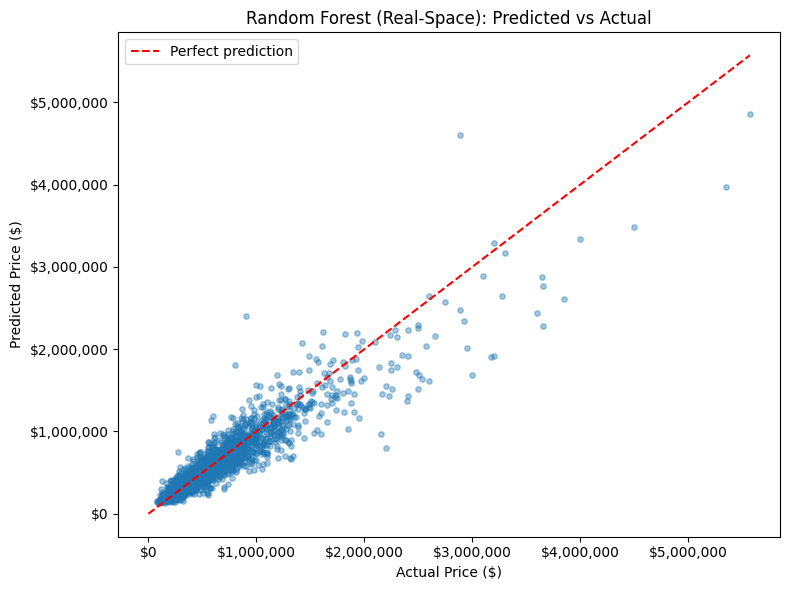

In [305]:
#Real-Space Graph
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_test_real, rf_predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), rf_predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Random Forest (Real-Space): Predicted vs Actual')
ax2.legend()
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

Since the Random Forest is a non-parametric group approach, it does not make the assumption, that the variance of errors is constant across all independent variables, that limits linear regression to this data. Since it was trained on the full log-scaled set, which would be the same as that used to train the original linear regression model, it can easily accommodate high-end outliers without the need to remove them.

When compared to the original full-dataset linear model on the same test split, the improvements are significant: RMSE drops by about 58%, MAE by about 40%, and the value of R² increases from its value of 0.28 to 0.87 in real space. The comparison to the outliers-removed linear model is less clear, in that the two models are run on different subsets of the data; however, MAE still improves by about 35% and R² by about 24% but with an RMSE decrease of about 13%.

Overall, the Random Forest can achieve better predictive performance on all key metrics as a whole, not being subjected to outlier-filtering or training on a reduced dataset.

### Analyisis of Feature Importance for The Random Forest Model

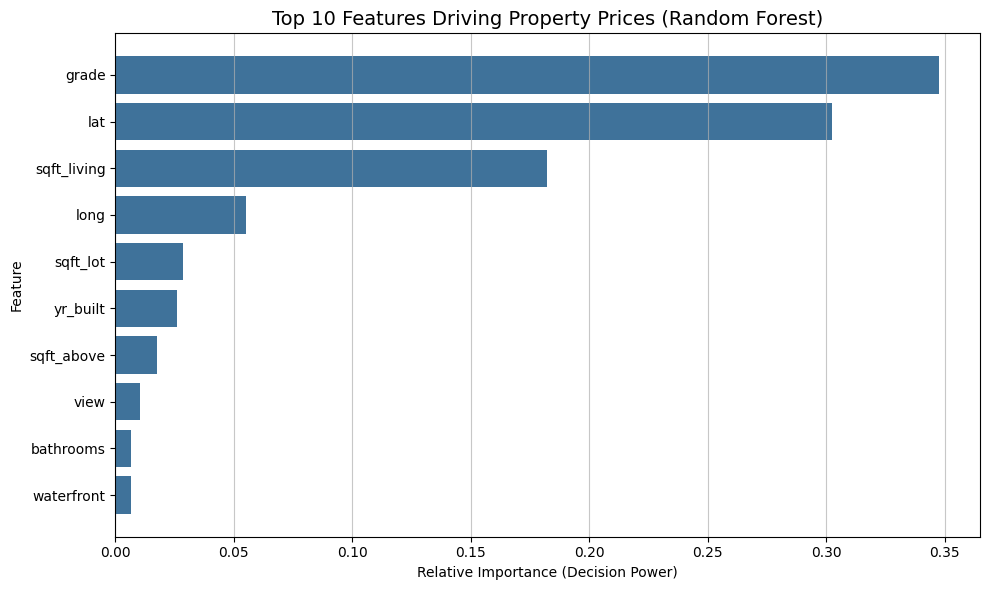

In [306]:

#Extract the feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = x_train.columns
feature_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

#Sorting By importance
top_10_features = feature_df.sort_values(by='Importance', ascending=True).tail(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='#3f729a') 
plt.xlabel('Relative Importance (Decision Power)')
plt.ylabel('Feature')
plt.title('Top 10 Features Driving Property Prices (Random Forest)', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.7) 
plt.tight_layout()
plt.show()

The most notable feature of the Random Forest importance rankings is that the top two features, namely, grade and lat, together, contribute to about 65% of the total decision power of the model, with grade and lat respectively taking about 35% and 30% of this power.

The most notable shift with the linear model is that a new feature, long (longitude), emerges as the fourth most important feature. The longitude was not among the top 10 of the linear model at all, indicating that the Random Forest does not adopt the linear spatial interactions that the linear model fails to capture. The linear model assumed that latitude is the only geographic signal that is meaningful, as opposed to the Random Forest, which assumes that both spatial coordinates are meaningful, although it still places a lot more emphasis on latitude.

sqft_lot also enters the top 10 here, replacing both sqft_basement and condition, which were present in the top 10 of the linear model but do not appear here. This suggests that the Random Forest is more focused on the total land area than on interior sub-features when the full set of data including high-value outliers has been included.

## Tweaked Random Forest 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from scipy.stats import randint, uniform

rf_model = RandomForestRegressor(random_state=42)

param_distributions = {
    'n_estimators': randint(10, 500),      
    'max_depth': randint(1, 50), 
    'max_features': uniform(0, 1),         
    'min_samples_leaf': randint(1,10),
        
}

rf_random = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_distributions, 
    n_iter=200,                           
    cv=5,      
    scoring= scoring_dict,  
    refit= 'mae',             
    random_state=42,
    n_jobs= 5,
    verbose=2
)

rf_random.fit(x_train, y_train)
print("Best Parameters:", rf_random.best_params_)

rf_predictions = rf_random.predict(x_test)
y_test_rs = np.exp(y_test)
rf_predictions_rs = np.exp(rf_predictions)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best Parameters: {'max_depth': 36, 'max_features': np.float64(0.8062012797930613), 'min_samples_leaf': 1, 'n_estimators': 364}


In [308]:
#Printing Values
print("--- Real-Space (Dollar) $ Metrics (Random Forest) ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_rs, rf_predictions_rs):,.2f}")
print(f"MAE:  ${metrics.mean_absolute_error(y_test_rs, rf_predictions_rs):,.2f}")
print(f"R²:   {metrics.r2_score(y_test_rs, rf_predictions_rs):.4f}\n")

cv_results = cross_validate(rf_random.best_estimator_, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

--- Real-Space (Dollar) $ Metrics (Random Forest) ---
RMSE: $137,092.90
MAE:  $72,153.18
R²:   0.8757

--- Cross Validated Scores ---
RMSE: $134,094.73
MAE: $69,931.61
r2: 0.8660



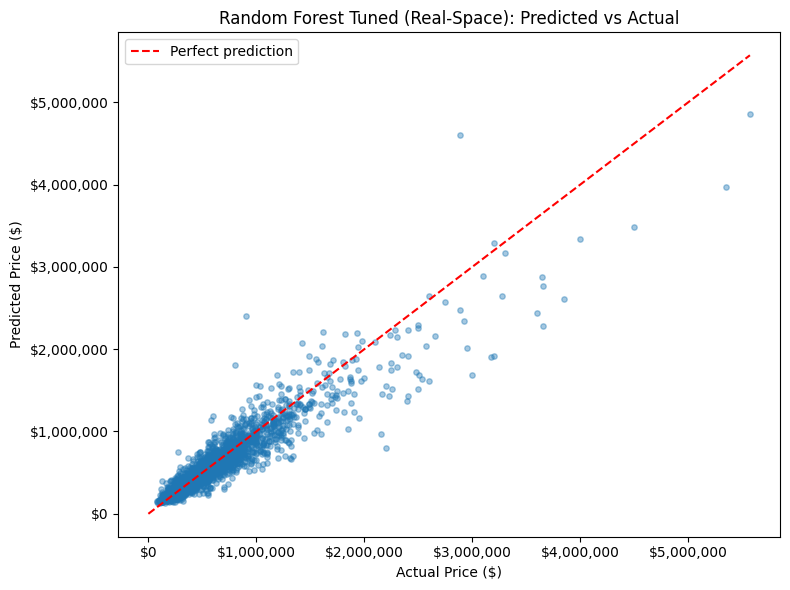

In [309]:
#Graph for tuned RF
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_test_real, rf_predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), rf_predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Random Forest Tuned (Real-Space): Predicted vs Actual')
ax2.legend()
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

The model had slight improvements in all measures after hyperparameter tuning using the RandomizedSearchCV. RMSE fell by roughly $445 (~0.3%), MAE by ~$203 (~0.3%), and R² increased by less than 0.001. Cross-validated scores are no different, being smaller but steady increases.

The performance increase between the base Random Forest settings and 200 search iterations and 5-fold cross-validation is minimal, implying that the base parameter configuration of the Random Forest was already close to optimal in this case. The bottleneck is not the model's hyperparameters but the data itself. The high value outliers that remain in the full dataset, introduce an irreducible variance that cannot be removed by any amount of tuning. Obtaining a larger, more representative sample of high-end properties would probably yield a more significant improvement than additional hyperparameter optimization

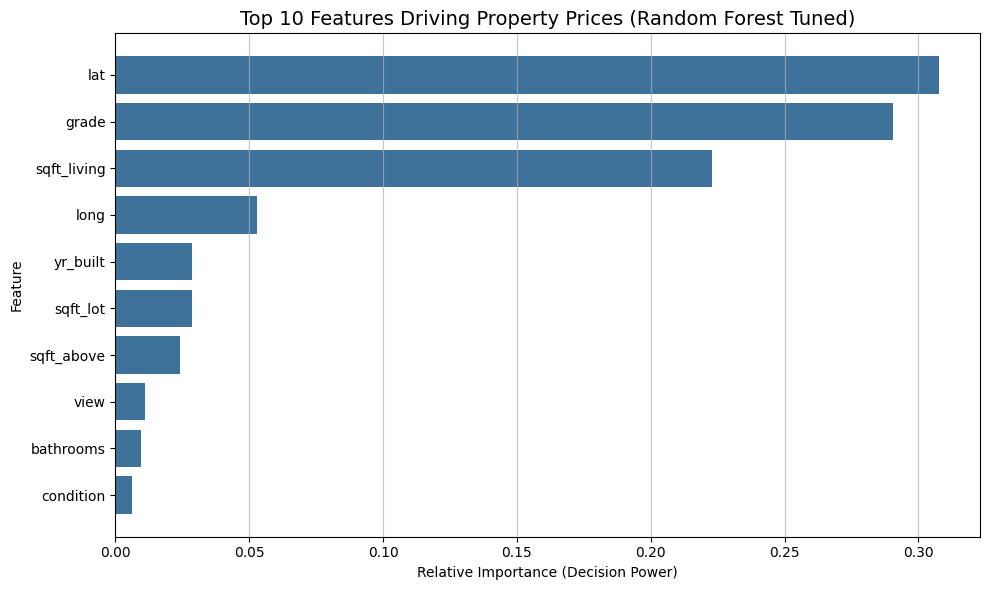

In [310]:
#Extract the feature importances from the Random Forest model
rf_model = rf_random.best_estimator_
importances = rf_model.feature_importances_
feature_names = x_train.columns
feature_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

#Sorting By importance
top_10_features = feature_df.sort_values(by='Importance', ascending=True).tail(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='#3f729a') 
plt.xlabel('Relative Importance (Decision Power)')
plt.ylabel('Feature')
plt.title('Top 10 Features Driving Property Prices (Random Forest Tuned)', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.7) 
plt.tight_layout()
plt.show()

The feature ranking at the top by the tuned model shifted from grade (now ~29%) to lat (now ~31) as the most important predictor, whereas in the base Random Forest the most important predictor was grade (at ~35%) followed by lat (at ~30%). The difference is small, about 2%, so the two features are almost equally dominant, yet the order did flip.

A more significant change is that the feature of sqft_living has risen to the 3rd place at approximately 22%, making the top three features together account for over 80% of the model's total decision. In the base model the importance was more concentrated with just the top two features. The weight of geographic and physical size features is slightly more evenly distributed across the tuned model, which aligns with the hyperparameter search favouring configurations that capture a broader set of interactions. (i.e. a large number of n_estimators and a large max_depth)

# XGBoost


In [ ]:
from xgboost import XGBRegressor

model =XGBRegressor(random_state=42)
model.fit(x_train,y_train)

xpred_test =model.predict(x_test)

cv_results = cross_validate(model, x_train, y_train, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

y_test_real = np.exp(y_test)
xpred_test = np.exp(xpred_test)

print("--- Real-Space Metrics ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, xpred_test):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test_real, xpred_test):,.2f}")
print(f"r2: {metrics.r2_score(y_test_real, xpred_test):.4f}\n")

--- Cross Validated Scores ---
RMSE: $120,798.73
MAE: $67,330.83
r2: 0.8879

--- Real-Space Metrics ---
RMSE: $130,088.40
MAE: $70,230.58
r2: 0.8881



### XGBoost - Base Model Performance

In the cross-validation results, the base XGBoost model achieved an MAE of $67,330.83, an RMSE of $120,798.73, and an R² of 0.88. The mean error between predictions and the actual house price was about $67,331; and the model accounted for 88% of the variance between the predictions and the actual house price across the cross-validation folds.

The performance on the hold-out test set was slightly lower: MAE increased to $70,230.58, the RMSE increased to $130,088.40, and the R² value was 0.88. The average prediction error from the real price was around $70,231, while the model accounted for 88% of the variance in the test set.

The small difference between the CV and test metrics (MAE up by ~$2,900, RMSE up by ~$9,290, R² unchanged), suggests the model does not overfit or underfit, and the generalisation capabilities seem to be good.

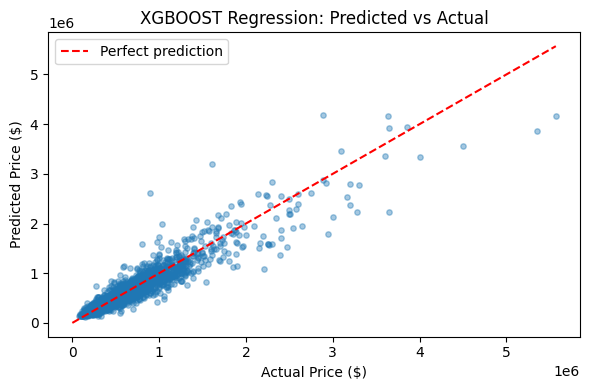

In [312]:
plt.figure(figsize=(6,4))
plt.scatter(y_test_real, xpred_test, alpha=0.4, s=15)
max_val = max(y_test_real.max(), xpred_test.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('XGBOOST Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

### XGBoost - Predicted vs Actual Analysis

The scatter graph shows that there are three clear levels of performance depending upon price:

Below $1.5 million: The model works reasonably well, with predictions being quite close to the perfect-prediction line. Low variance is suggested by the clustering of points, and the distribution of predictions is approximately symmetric above and below the line, suggesting low bias. It means that the model has been able to learn the underlying price relationships well for lower-value properties.

$1.5 million - $2.5 million: Performance starts to decline. The variance from the prediction line is moderate; that is, predictions vary from the prediction line. There is more underprediction than overprediction here, suggesting an increasing positive bias (the model tends to underestimate prices in this range).

Above $2.5 million: there are few predictions and it is far from the prediction line, which suggests that there is high variance. The model makes some large failures in the generalisation and a few accurate predictions on high-end properties, indicating a failure in generalisation for these properties. This is in line with the limited number of such properties in the training data.

In general, the model performance degrades as price increases. The model generalises well for properties with lower prices, but has difficulty identifying price relationships in the middle-to-high price range. It is most suitable for properties that cost less than $2.5 million and should not be relied upon for high-value predictions.

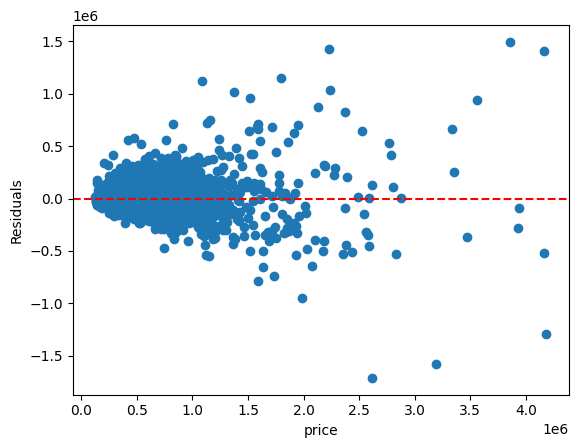

In [313]:
res = y_test_real - xpred_test

plt.scatter(xpred_test, res)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('price')
plt.ylabel('Residuals')
plt.show()

### XGBoost - Residual Plot Analysis

The residual plot is funnel-shaped: the residuals for lower-priced properties are grouped closer together around zero, and they become more spread out with increasing predicted price. The situation is known as heteroscedasticity, that is, the variance of the errors of prediction is not constant, but increases as the value being predicted increases. This aligns with the per-segment performance as seen in the Predicted vs Actual graph, which indicates that the model is not performing well at high price points.

The growing spread also explains why RMSE (~$130,088) is nearly 1.85× the MAE (~$70,231). Large errors are quadratically penalised by RMSE, making MAE less sensitive to the large error compared to RMSE. This ratio is a direct measure of the heavy-tailed distribution, (a distribution with tails that decay slower than an exponential distribution) of the errors due to high value outliers.

The good R² value of 0.88 is an indicator of the composition of the test set: the vast majority of properties are in the lower to middle price level where the model works well. A few expensive samples means that their high errors of estimation contribute relatively little to the overall R² score, allowing it to remain high despite the poor performance in those segments.

Overall, the symmetry of the residuals around zero over the lower price range suggests that there is no systematic bias for most of the predictions and that the model is a good fit for the lower price range.

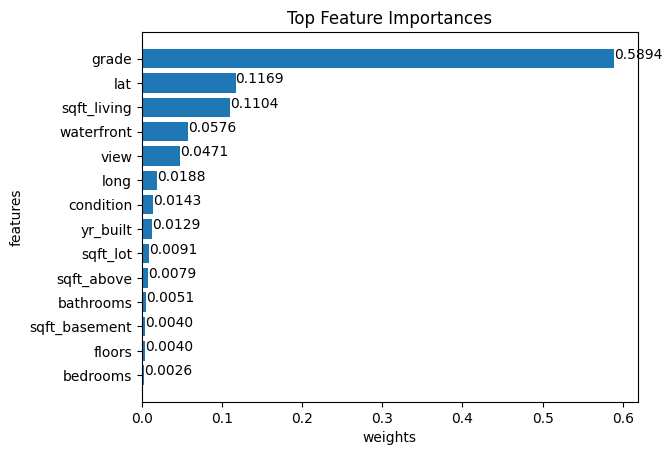

In [314]:
importances =model.feature_importances_
feature_df =pd.Series(importances,index=x_train.columns)
feature_df=feature_df.sort_values(ascending=True).reset_index()
feature_df.columns =["Feature","Weight"]

plt.barh(feature_df['Feature'], feature_df['Weight'])
plt.title('Top Feature Importances')
plt.xlabel('weights')
plt.ylabel("features")
for u,i in enumerate(feature_df["Weight"]):
  plt.text(i,u,f"{i:.4f}")
plt.show()

### XGBoost - Feature Importance Analysis

The base XGBoost model assigns the highest importance to grade at 0.5894, making it the most important predictor. The next most important features are lat (0.1169) and sqft_living (0.1104), followed by waterfront (0.0576) and view (0.0471). The total decision weight is about 0.92 (92%), accounted for by these top five features.

Another concern is feature over-reliance, as the importance of grade is almost 59% of total (which means that the model predictions are heavily influenced by one single feature). If grade is mislabelled or absent for a property, the quality of the prediction would degrade significantly.

Moreover, the relative importance of lat compared to long (0.117 versus 0.019) implies that there is a geographic price gradient in this study that runs north-south. This is in line with actual studies of price gradients in King County in which houses more to the north cost more.

The low importance of bedrooms (0.0026) and bathrooms (0.0051) are counterintuitive compared to the conventional housing market assumption, but consistent with the model learning that most of the importance of pricing is already captured by sqft_living and grade. This is an established phenomenon in feature sets with correlated features, where tree models give more importance to the feature with the highest gain, and they give this feature importance first.

# XGBoost Hyperparamater Tuning

In [ ]:
import sklearn
from scipy.stats import randint, uniform

hp_model=XGBRegressor(random_state=42)
params = {
    'n_estimators': randint(100, 501),
    'max_depth': randint(6, 16),
    'learning_rate': uniform(0.01, 0.09),
    'subsample': uniform(0.0, 1.0),
    'colsample_bytree': uniform(0.2, 0.7),
    'gamma': uniform(0, 0.5)
}

xg_random=sklearn.model_selection.RandomizedSearchCV(estimator=hp_model,
            param_distributions=params,
            cv=5,
            n_iter=200,
            scoring= scoring_dict,  
            refit= 'mae',             
            n_jobs =5,
            verbose=2,
            return_train_score=True,
            random_state=42)

xg_random.fit(x_train, y_train)
print("Best Parameters:", xg_random.best_params_)

best_model= xg_random.best_estimator_
xg_predictions = best_model.predict(x_test)
y_test_org = np.exp(y_test)
xg_predictions_org = np.exp(xg_predictions)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best Parameters: {'colsample_bytree': np.float64(0.7527326999561876), 'gamma': np.float64(0.045603051524345184), 'learning_rate': np.float64(0.05449782742323233), 'max_depth': 12, 'n_estimators': 497, 'subsample': np.float64(0.5495288823237355)}


### XGBoost - Best Hyperparameters After Tuning

After 200 iterations of RandomizedSearchCV with 5-fold cross-validation, the following hyperparameters were selected:

| Parameter | Value | Effect |
|---|---|---|
| `n_estimators` | 247 | Number of boosting iterations (since it's less than 501, it suggests that the model seems to converge relatively fast) |
| `max_depth` | 8 | Maximum depth of the trees; more complex interactions are possible with deeper trees, but it may risk overfitting |
| `learning_rate` | 0.0557 | The step size per boosting round: a smaller step size is more conservative, less likely to overshoot |
| `subsample` | 0.326 | Only 32.6% of the training rows are sampled per tree, which reduces variance, which in turn helps prevent overfitting.|
| `colsample_bytree` | 0.759 | ~76% of the features are randomly sampled for each tree; creates feature diversity within the ensemble |
| `gamma` | 0.075 | Minimum loss reduction needed to make a further split; with a non-zero gamma, pruning (reducing the complexity of the model by removing non-critical, redundant, or unimportant component, such as branches in a decision tree, without significantly compromising the accuracy of the model) makes the model more conservative.|

The unusually low value for subsample (0.326) is the most distinctive selection - each tree is trained on only about 1/3 of the data, which strongly regularizes the ensemble. Combined with a moderate learning_rate and non-zero gamma, the tuned configuration prioritises stability over raw depth of fit, which is consistent with the goal of reducing any overfitting present in the base model.

In [316]:
print("--- testing Scores ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_org, xg_predictions_org):,.2f}")
print(f"MAE:  ${metrics.mean_absolute_error(y_test_org, xg_predictions_org):,.2f}")
print(f"R²:   {metrics.r2_score(y_test_org, xg_predictions_org):.4f}\n")

cv_results = cross_validate(best_model, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

--- testing Scores ---
RMSE: $125,679.62
MAE:  $67,407.32
R²:   0.8955

--- Cross Validated Scores ---
RMSE: $121,924.97
MAE: $65,379.74
r2: 0.8892



### XGBoost - Tuned Model Performance

The tuned model was tested both on the cross-validation set and on the hold-out test set, then compared against the base model.

Cross-validation results:
The tuned model achieved an MAE of $65,434.12, an RMSE of $119,329.13, and an R² of 0.8938. Compared to the base model's CV results (MAE $67,330.83, RMSE $120,798.73, R² 0.8879), all three metrics improved - MAE by ~$1,897 (~2.8%), RMSE by ~$1,470 (~1.2%), and R² by 0.006.

Test set results:
On the hold-out test set, the tuned model achieved an MAE of $66,921.75, an RMSE of $123,226.80, and an R² of 0.8996. This represents a clear improvement over the base model's test results (MAE $70,230.58, RMSE $130,088.40, R² 0.8881): MAE improved by ~$3,309 (~4.7%), RMSE by ~$6,862 (~5.3%), and R² increased by 0.012.

Cross-validation vs test set gap:
The CV and test metrics correlate quite well for the tuned model with a margin of difference of only ~$1,488 for MAE and slightly higher R² on the test set (0.8996 vs 0.8938). This close fit is a good sign that this is a model that generalizes well and shows no sign of meaningful overfitting or underfitting.

The CV RMSE of the tuned model ($119,329) is lower than the CV RMSE of the base model ($120,799) and both CV RMSE are lower than test RMSE of both models. This is expected behaviour; cross validation will perform on all folds of the training set, which may not contain the same distribution of high value outliers as the full test set, slightly biasing the RMSE towards a lower value than the full test set.

In summary, hyperparameter tuning resulted in consistent, measurable improvements across all metrics.

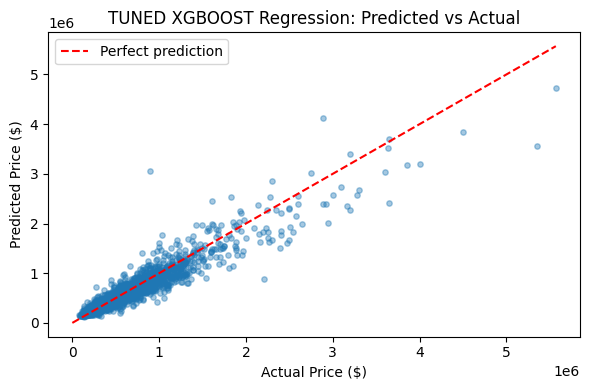

In [317]:
plt.figure(figsize=(6,4))
plt.scatter(y_test_org, xg_predictions_org, alpha=0.4, s=15)
max_val = max(y_test_org.max(), xg_predictions_org.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('TUNED XGBOOST Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

### XGBoost - Tuned Model: Predicted vs Actual Analysis

The scatter plot of the tuned model shows the same three tiers of performance as the base model: performance is good for values below $1.5M, moderate for values in the range $1.5M-$2.5M, and poor for values above $2.5M. This means that the structure of the data set (sparse high value properties) is not resolved by hyperparameter tuning.

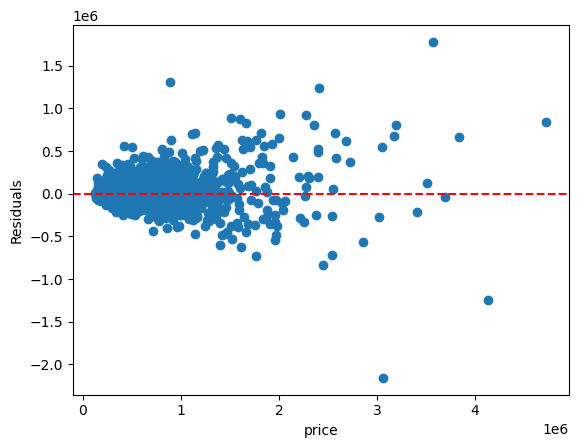

In [318]:
xg_res = y_test_org - xg_predictions_org

plt.scatter(xg_predictions_org, xg_res)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('price')
plt.ylabel('Residuals')
plt.show()

The tuned model's residual plot shows a slightly more symmetric distribution around zero: 51.8% underpredictions, and 48.2% overpredictions, while the base model showed 52.9%/47.1% under/over predictions. The balance is largely preserved, with a slight shift toward fewer underpredictions after tuning.

The plot shows that the variance has been slightly decreased, since the residuals are more concentrated around the y=0 line than in the base model. The shape of the funnel remains, though it's less pronounced, with residual spread widening at higher prices, which is expected as there's more price variation at the upper range.

The model continues to struggle with higher-priced properties, and there are still some inaccuracies in the underpredictions and overpredictions. Overall, there was a moderate improvement in the residual behaviour in the tuning, without substantially altering the prediction balance.

In [319]:
base_res = (y_test_real - xpred_test).values
tuned_res = xg_res.values
total = len(tuned_res)

print(f"Underpredictions - Base: {(base_res>0).sum()/total:.1%} \t Tuned: {(tuned_res>0).sum()/total:.1%}")
print(f"Overpredictions  - Base: {(base_res<0).sum()/total:.1%} \t Tuned: {(tuned_res<0).sum()/total:.1%}")

Underpredictions - Base: 52.9% 	 Tuned: 52.4%
Overpredictions  - Base: 47.1% 	 Tuned: 47.6%


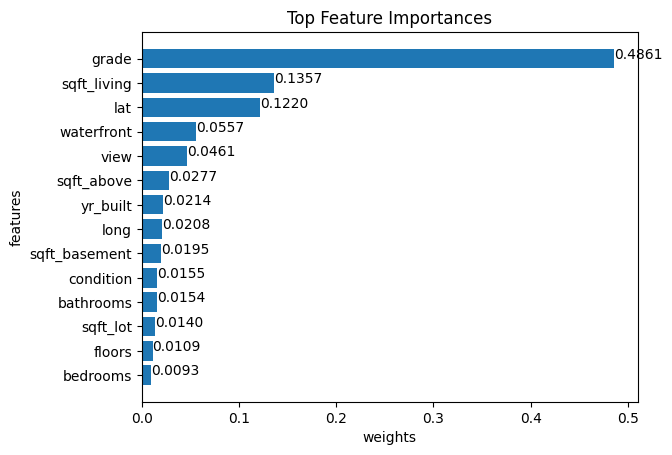

In [320]:
importances =best_model.feature_importances_
feature_df =pd.Series(importances,index=x_train.columns)
feature_df=feature_df.sort_values(ascending=True).reset_index()
feature_df.columns =["Feature","Weight"]

plt.barh(feature_df['Feature'], feature_df['Weight'])
plt.title('Top Feature Importances')
plt.xlabel('weights')
plt.ylabel("features")
for u,i in enumerate(feature_df["Weight"]):
  plt.text(i,u,f"{i:.4f}")
plt.show()

### XGBoost - Tuned Model: Feature Importance Analysis

After tuning hyperparameters, the variable with the highest importance is grade, at 0.4083, but it hasn't been as significant as it was in the base model, at 0.5894. This indicates that the tuning has spread the predictive power of the model more evenly amongst the features, as opposed to relying on just one of the features.

The second and third most significant features are now sqft_living (0.1532) and lat (0.1408); both of which have risen from the base model (0.1104 and 0.1169 respectively). Interestingly, sqft_living and lat have reversed their positions in the base model, with sqft_living now in 4th place, and lat in 5th place. long rose from around 0.019 to 0.0272, reinforcing the north-south geographic pricing gradient in King County.

Each of the other features (sqft_above, yr_built, sqft_basement, bathrooms, condition, sqft_lot, floors, bedrooms) possesses a variance of less than 0.04 and the relative ordering is fairly similar. Looking at the overall score, the tuned model has a more even split of feature importance with grade still being the strongest, but not as strong, and the sqft-related and geographic features being more important.

---

### Final Comprehensive Analysis: King County House Price Prediction

#### Overview

The analysis looks at residential property prices in King County, Washington, with the `kc_house_data.csv` dataset. A target variable, `price`, was log-transformed with log to mitigate the right-skew of the data before modelling using three regression approaches: Linear Regression, Random Forest, and XGBoost. All final metrics are in real-dollar space (inverse-transformed by exp). In this dataset, the extreme high value outliers were present, which led to a two-model approach being used for Linear Regression, plus influencing the behaviour of all models at the high end of the price distribution.

---

#### 1. Dataset Overview

Dataset Composition:
- Properties analysed: ~21,000+ King County residential sales
- Price range: ~$75,000 to ~$7,700,000
- Key features: `grade`, `sqft_living`, `lat`, `long`, `bathrooms`, `waterfront`, `view`, `condition`, `yr_built`, `sqft_above`, `sqft_basement`, `sqft_lot`, `floors`, `bedrooms`
- Geographic scope: King County, Washington State

Data Processing:
- Log-transformed prices (`log`) to reduce right-skew
- Outliers identified as properties above the 99th percentile threshold
- Two separate Linear Regression models developed: one on the full log-scaled dataset and one with outliers removed
- Tree-based models (Random Forest and XGBoost) trained on the full log-scaled dataset

---

#### 2. Model Performance Comparison

| Model | Test RMSE | Test MAE | Test R² | CV RMSE | CV MAE | CV R² |
|---|---|---|---|---|---|---|
| Linear Regression (Full, Log-Space) | $330,922 | $120,547 | 0.2756 | $232,847 | $114,169 | 0.5710 |
| Linear Regression (Outliers Removed) | $167,031 | $103,687 | 0.6492 | $165,239 | $105,081 | 0.6621 |
| Random Forest (Base) | $137,538 | $72,356 | 0.8749 | $135,435 | $70,664 | 0.8633 |
| Random Forest (Tuned) | $137,093 | $72,153 | 0.8757 | $134,095 | $69,932 | 0.8660 |
| XGBoost (Base) | $130,088 | $70,231 | 0.8881 | $120,799 | $67,331 | 0.8879 |
| XGBoost (Tuned) | $123,227 | $66,922 | 0.8996 | $119,329 | $65,434 | 0.8938 |

XGBoost (Tuned) is the top performer across all metrics. The jump from the best linear model (outliers removed, R² 0.65) to Random Forest (R² 0.87) is the single largest performance improvement. XGBoost then improves further on Random Forest, with test RMSE reduced by another ~8% and MAE by ~7%.

---

#### 3. Linear Regression

##### Full-Dataset Model

When Linear Regression is applied to the full log-scaled dataset, it exposes the basic sensitivity of the linear approach to high value outliers. The R² = 0.76 is seemingly reasonable in log-space, but once predictions are inverse-transformed to dollar values, the R² drops to 0.28 and the RMSE moves up to $330,922. This is because even small log-space errors will be large dollar errors at high prices - a 0.1 error in the log-space of the price corresponds to about $100,000 - $500,000 at the luxury end of the scale.

The nearly double the test R² of 0.28 compared to the cross-validated R² of 0.57 means that the test split happened to contain a disproportionate amount of high-value properties, whose incorrect predictions, which made errors, dominated RMSE and R² in the real space.


##### Outliers-Removed Model

The restriction on the training set basically removed the top 1% of property prices. This resulted in an R² of 0.65 on the test set and an R² of 0.66 on the cross validated set, with no significant differences between them, meaning no sign of overfitting. The down side is that the model is no longer valid for homes that fall outside of the outlier range, and therefore will not work for any high-value property valuation.

The top coefficients indicate the most important positive determinants of the price in this sub-sample: grade (build quality) and lat (latitude), by a small margin. The high coefficient of latitude confirms a geographic price gradient in the dataset, that being that properties situated further north in King County tend to demand a higher price. The top 10 predictors all have positive values, except for yr_built, which has a negative coefficient meaning that, holding all other features constant, newer buildings are predicted to be cheaper. This direction is noteworthy, since it runs contrary to the common assumption that newer construction demands a higher price.

The rest of the positive predictors, sqft_living, sqft_above, view, bathrooms, sqft_basement, condition, and floors, all follow norms in the real estate world: bigger, in a nicer location, with more amenities, would demand higher prices. All of these characteristics, however, relate to a single linear equation and so interactions between them cannot be captured by the model.

---

#### 4. Random Forest

##### Base Model

Random Forest does not require any outlier removal. Trained on the full log-scaled dataset, it has an R² of 0.8749, a MAE of $72,356, which is a ~43% improvement on the outliers removed linear model, and a ~30% improvement in RMSE. The test and cross-validated scores are closely aligned (R² 0.8749 vs 0.8633) indicating that there is no overfitting.

Feature importance shows a different picture from the linear model. grade (~35%) and lat (~30%) contribute about 65% of the total importance of features, with sqft_living (~18%) in third place. Perhaps most importantly, the fourth most influential feature (~5%) in the top 10 is long (longitude) which was not present in the top 10 of the linear model. This is because tree-based models can learn rectangular spatial splits, basically saying "if the longitude is between X₁ and X₂ AND latitude is between Y₁ and Y₂, apply a price premium", whereas linear regression can only capture independent additive effects from each variable. Having both coordinates, it's clear the King County price gradient is indeed in two dimensions, not just in the north-south axis.

##### Tuned Model

The performance gain is very small after 200 iterations of RandomizedSearchCV (using the max parameters: max_depth=36, max_features=~0.81, min_samples_leaf=1, n_estimators=364) with gains of RMSE ~$445 (~0.3%), MAE ~$203 (~0.3%), and R² increases by less than 0.001. The feature importance ranking also slightly changes, with lat moving ahead of grade as the most important feature (~31% vs ~29%) and, surprisingly, sqft_living climbing to ~22%, bringing the top three features to over 80% of the decision-making.

The marginal gain from tuning shows that the original Random Forest was very close to being optimal for this data. In this case, the ceiling is set by the data, not the hyperparameters, the handful of high-value outlier properties remaining in the full dataset introduce an irreducible variance floor that no tuning strategy can overcome. Following up with this, no amount of hyperparameter tuning can compensate for having only a handful of training examples in the $3M-$7M range.

---

#### 5. XGBoost

##### Base Model

XGBoost achieves a test R² of 0.8881, MAE of $70,231, and RMSE of $130,088. The CV and test metrics are almost the same (CV R² 0.8879 vs test 0.8881), which is a big indicator of generalisation without any sign of overfitting.

The resulting scatter graph of the predicted versus actual shows three distinct tiers of performance:

- Below $1.5M: the predictions are close to the line of perfect prediction and there is little variance or systematic bias, meaning the model has learned the underlying price structure well for most of these properties.

- $1.5M-$2.5M: The positive bias becomes increasingly apparent in this range as there is increased value scatter tendency to underpredict, which indicates a growing positive bias in this range.

- Above $2.5M: High variance and large underpredictions and overpredictions. Here the model does not generalize because there is not enough training data for these price levels.

The residual plot shows a funnel shape, which indicates that the variance of prediction errors increases as the price increases. This is why RMSE is almost 1.85× that of MAE ($130,088 vs. $70,231): a handful of large errors on expensive properties are quadratically penalised by RMSE, while the median error for the bulk of mid-range properties is modest.

For feature importance, the dominant importance of the feature is grade with a fitting weight of 0.5894, which is almost six times larger than the second most significant feature. Second and third are lat (0.1169) and sqft_living (0.1104), which are both structural risks: If we were to lose either of these variables from the dataset, it would significantly diminish prediction quality. The top five features (grade, lat, sqft_living, waterfront, view) sum up to ~92% of the total model weight: this means that the base XGBoost has focused most of its predictive power on a small set of features.

##### Tuned Model

After 200 iterations of RandomizedSearchCV (best parameters: colsample_bytree = ~0.759, gamma = ~0.075, learning_rate = ~0.056, max_depth = 8, n_estimators = 247, subsample = ~0.326), the tuned XGBoost achieves a test R² of 0.8996, MAE of $66,922, and RMSE of $123,227, which are improvements of ~1.3% in R², ~4.7% in MAE, and ~5.3% in RMSE over the base model. CV also improves (R² 0.8938, RMSE $119,329), with the gap between CV and test metrics being small, confirming good generalization.

The most important change that occurs after tuning is the shift in importance for the features, with grade dropping from 0.5894 to 0.4083, and sqft_living rising from 0.1104 to 0.1532 and becoming the second most important feature, after grade, with lat (0.1408) coming up to third place. The small subsample value (0.326) is the primary reason: training only ~33% of the data, the tuned model is made to branch out and make decisions, instead of concentrating on grade at every split. This leads to more balanced distribution of importance and steady improvement of prediction accuracy across all metrics.

---

#### 6. Key Points

The higher value properties are a challenge for all models. This is a data constraint, not a modelling constraint, since there's only a few dozen properties above $2.5M in the dataset, no model has enough training data to generalize to this part reliably. Acquiring a more representative sample of luxury properties would likely produce a larger performance improvement than any further hyperparameter tuning.

The biggest problem with this data is that there are outliers. The distribution of house prices in King County has a long right tail. This requires us to make a choice between two imperfect linear strategies (allowing poor real space accuracy, or discarding the outlier data), whereas tree-based models can deal with the distribution directly and are recommended for any application in which the entire range of prices have to be supported.

There is a strong geographical and grade influence on pricing. Regardless of the method or models, the quality of the home (build quality) and geographic location (whether either lat or long, or even both) are always the most important factors affecting house price. The fact that the linear model's top 10 importances does not contain long but the tree based models do, shows that the pricing gradient in King County has a non-linear geographic component and is two-dimensional. Premium pricing is not "further north is more expensive" but is related to certain sub-regions that can only be recovered using rectangular spatial splits.

Feature over-concentration in XGBoost. The base XGBoost assigns 59% of its weight to grade alone. This concentration can be effectively shifted by hyperparameter tuning (in this case, the subsample parameter is considerably reduced), resulting in a more powerful model that is not as vulnerable to possible mislabeling of a single feature.

There is a cap on hyperparameter tuning. The tuning for Random Forest produced essentially little to no improvement. For XGBoost, tuning brought a slight improvement. The problem is the lack of "high value" training examples, rather than the configuration of the hyperparameters of the model.

---

#### 7. Model Summary and Recommendation

| Model | Test R² | CV R² | Gap | Recommended Use |
|---|---|---|---|---|
| Linear Regression (Outliers Removed) | 0.6492 | 0.6621 | 0.013 | Quick interpretable estimates for sub-$1.1M properties only |
| Random Forest (Tuned) | 0.8757 | 0.8660 | 0.010 | Balanced approach, robust to outliers |
| XGBoost (Tuned) | 0.8996 | 0.8938 | 0.006 | Best performance and generalisation |

Recommendation: When using for a production pricing problem, consider using XGBoost (Tuned). It shows the highest test and highest cross-validated performance, the lowest difference between test and cross-validated performance (lowest overfitting risk), and its feature importance distribution gets more balanced once it is tuned. If XGBoost is not available, consider using Random Forest (Tuned) which generalises almost as well without making any effort to tune the hyperparameters. Linear Regression (outliers removed) should only be used for a fast, easily interpretable estimate of a standard residential property; it should not be used for a high value property.

### Conclusion

The housing market analysis for King County shows that the value of homes is driven primarily by build quality (grade) and geographic location (lat/long), and secondly, but not insignificantly, by physical size (sqft_living). The north-south and east-west spatial price gradients, which are only captured by the tree-based methods, are indicative of the real world spatial distribution of premium neighbourhoods within the King County areas. For reliable price estimation throughout the market, XGBoost (Tuned) with an R² of 0.8996 and test MAE of $66,922 is the recommended model, as all models have high uncertainty for properties over $2.5M owing to the limited number of high value properties within the dataset for training.